In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
## opens sqlite database

conn = sqlite3.connect("./data/game.db")

def statement_to_df(s: str):
    cursor = conn.cursor()
    cursor.execute(s)
    conn.commit()
    cols = [description[0] for description in cursor.description]
    list = cursor.fetchall()
    df = pd.DataFrame(list, columns=cols)
    return df

def get_tables():
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    return [table[0] for table in tables]

    

def plot_statement(s: str):
    df = statement_to_df(s)
    ## now plot
    plt.plot(df)
    plt.show()

In [3]:
def ships_over_frame():
  result = statement_to_df("""
    with combined as (select * from (select frame, 1 as val from ships_created
    union all 
    select frame, -1 as val from ships_destroyed)
    order by frame
  )
                  
  select x, sum(y) over (order by x) as y from (select frame as x, sum(val) as y from combined group by frame);
  """)
  return result

In [4]:
get_tables()

['ships_destroyed',
 'ships_created',
 'players',
 'servers',
 'server_ticks',
 'pings',
 'player_counts']

Text(0, 0.5, 'Players')

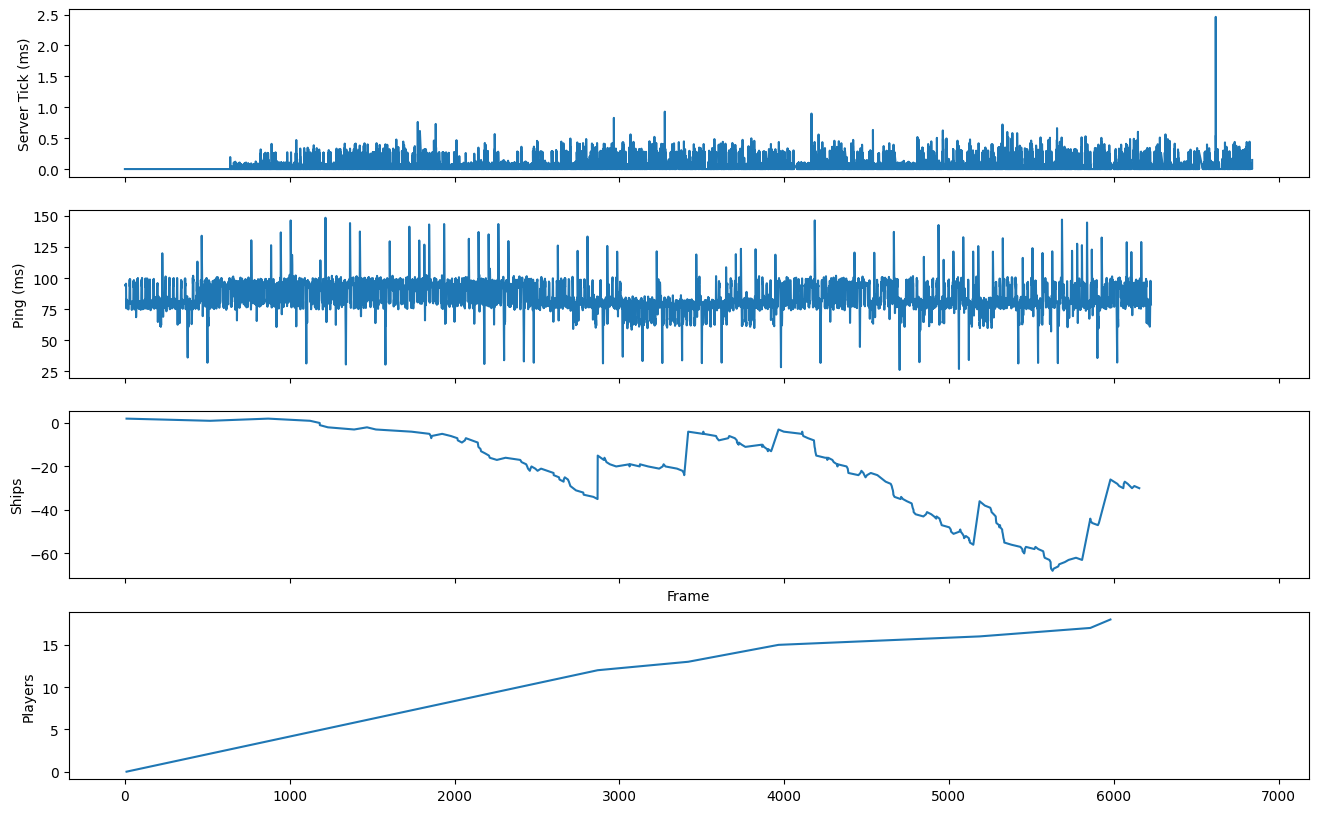

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(16,10), sharex = True)
ticks = statement_to_df("select tick as x, micros_elapsed / 1000.0 as y from server_ticks")
axes[0].plot(ticks["x"], ticks["y"], )
axes[0].set_ylabel("Server Tick (ms)")

pings = statement_to_df("select tick as x, micros/1000.0 as y from pings")
axes[1].plot(pings["x"], pings["y"])
axes[1].set_ylabel("Ping (ms)")

ships = ships_over_frame()
axes[2].plot(ships["x"], ships["y"])
axes[2].set_ylabel("Ships")

player_counts = statement_to_df("select tick as x, count as y from player_counts")
axes[3].plot(player_counts["x"], player_counts["y"])
axes[3].set_ylabel("Players")
axes[3].set_xlabel("Frame")
